In [17]:
import subprocess
import json
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

In [18]:
# Define paths
executable_path = "../build/Release/BM_SeqWRite"

# Verify executable exists, build if missing
if not os.path.exists(executable_path):
    print(f"Executable not found at {executable_path}. Attempting to build...")
    
    # Run conan build command from project root (parent directory)
    build_cmd = ["conan", "build", ".", "-pr", "conan/profiles/clang20", "-b", "missing"]
    
    print(f"Running build command: {' '.join(build_cmd)}")
    try:
        # cwd='..' to run from project root
        # Using check=True to raise exception on failure
        build_result = subprocess.run(build_cmd, cwd="..", check=True, capture_output=True, text=True)
        print("Build completed successfully.")
        # print(build_result.stdout) # Uncomment to see build output
    except subprocess.CalledProcessError as e:
        print("Build failed.")
        print("Error output:")
        print(e.stderr)
        print("Standard output:")
        print(e.stdout)

    # Re-check if executable exists after build
    if os.path.exists(executable_path):
        print(f"Found executable at {executable_path}")
    else:
        print("Warning: Build appeared successful but executable is still missing.")
else:
    print(f"Found executable at {executable_path}")

Found executable at ../build/Release/BM_SeqWRite


In [19]:
# Run the benchmark
# We filter for BM_WriteToArray just in case there are others, though the source implies it's the main one.
cmd = [executable_path, "--benchmark_format=json", "--benchmark_filter=BM_WriteToArray"]

print(f"Running command: {' '.join(cmd)}")
result = subprocess.run(cmd, capture_output=True, text=True)

data = None
if result.returncode != 0:
    print("Error running benchmark:")
    print(result.stderr)
    print(result.stdout)
else:
    print("Benchmark finished successfully.")
    try:
        data = json.loads(result.stdout)
    except json.JSONDecodeError:
        print("Failed to decode JSON output. Raw output:")
        print(result.stdout)


Running command: ../build/Release/BM_SeqWRite --benchmark_format=json --benchmark_filter=BM_WriteToArray
Benchmark finished successfully.


In [ ]:
#print(data)
if data:
    # Parse results
    benchmarks = data.get('benchmarks', [])
    sizes = []
    bandwidths = []

    for b in benchmarks:
        # The benchmark uses ->Arg(N), so the value N is usually part of the name "Name/N"
        name = b["name"]
        
        # Look for MemBW counter
        if "MemBW" in b:
            bw = b["MemBW"]
            
            # Extract size from name components
            # name format example: BM_WriteToArray/4096/threads:1
            parts = name.split('/')
            arg = None
            for part in parts:
                try:
                    arg = int(part)
                    break
                except ValueError:
                    continue
            
            if arg is not None:
                sizes.append(arg)
                bandwidths.append(bw)

    # Convert to DataFrame
    df = pd.DataFrame({'Size_Bytes': sizes, 'Bandwidth_GBs': [bw / 1e9 for bw in bandwidths]})
    df = df.sort_values('Size_Bytes')

    print(f"Collected {len(df)} data points.")
    print(df.head())

{'context': {'date': '2026-01-24T23:09:50-08:00', 'host_name': 'aliaksei-tt', 'executable': '../build/Release/BM_SeqWRite', 'num_cpus': 32, 'mhz_per_cpu': 5756, 'cpu_scaling_enabled': True, 'aslr_enabled': False, 'caches': [{'type': 'Data', 'level': 1, 'size': 49152, 'num_sharing': 2}, {'type': 'Instruction', 'level': 1, 'size': 32768, 'num_sharing': 2}, {'type': 'Unified', 'level': 2, 'size': 1048576, 'num_sharing': 2}, {'type': 'Unified', 'level': 3, 'size': 33554432, 'num_sharing': 16}], 'load_avg': [0.780273, 0.483398, 0.404785], 'library_version': 'v1.9.4', 'library_build_type': 'release', 'json_schema_version': 1}, 'benchmarks': [{'name': 'BM_WriteToArray/4096/threads:1', 'family_index': 0, 'per_family_instance_index': 0, 'run_name': 'BM_WriteToArray/4096/threads:1', 'run_type': 'iteration', 'repetitions': 1, 'repetition_index': 0, 'threads': 1, 'iterations': 40914008, 'real_time': 15.672103769442353, 'cpu_time': 15.671421900293904, 'time_unit': 'ns', 'MemBW': 261367476803.31308,

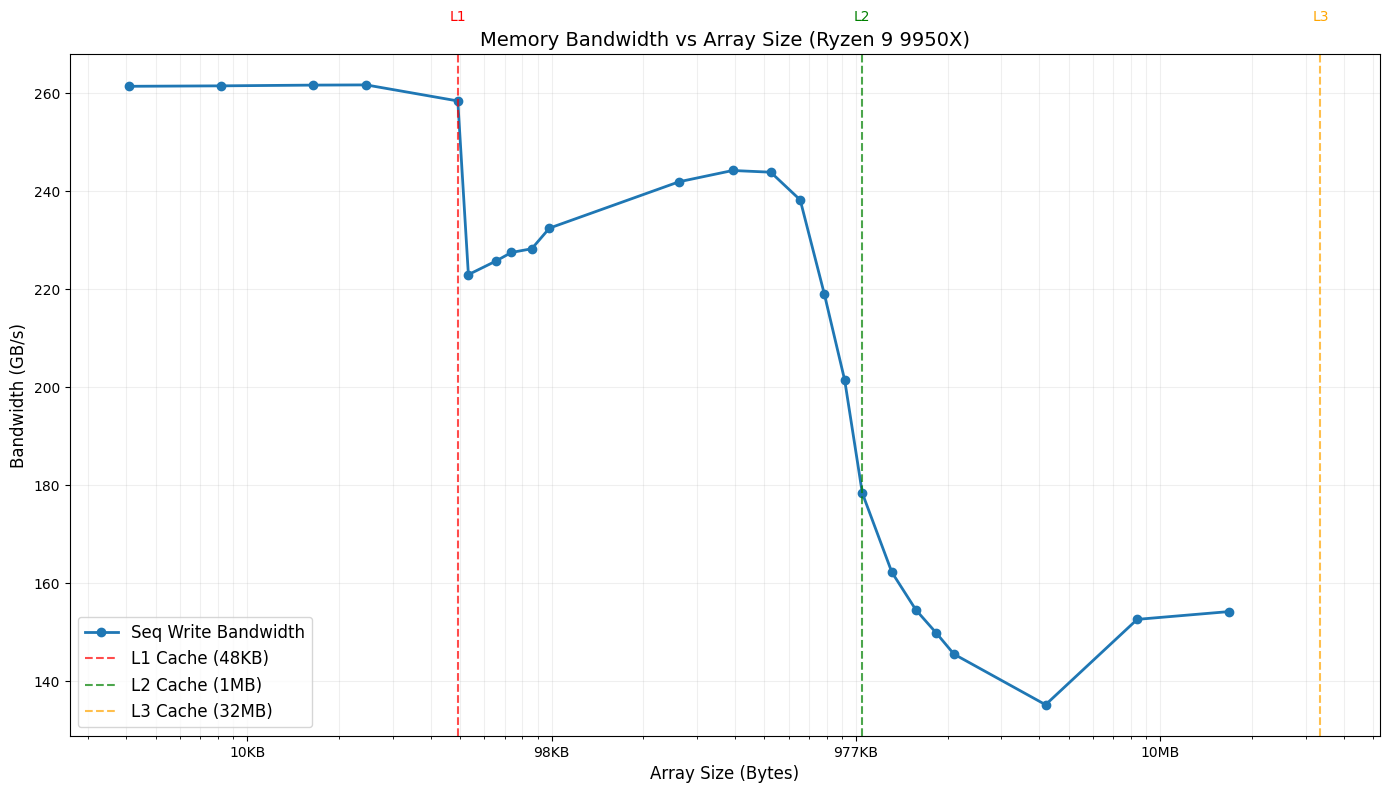

In [21]:
if data and not df.empty:
    # Plotting
    plt.figure(figsize=(14, 8))
    plt.plot(df['Size_Bytes'], df['Bandwidth_GBs'], marker='o', linestyle='-', linewidth=2, label='Seq Write Bandwidth')

    # Cache sizes for Ryzen 9 9950X
    # L1 Data: 48KB
    # L2: 1MB
    # L3: 32MB (per CCD)
    l1_size = 48 * 1024
    l2_size = 1 * 1024 * 1024
    l3_size = 32 * 1024 * 1024

    # Vertical lines
    plt.axvline(x=l1_size, color='r', linestyle='--', alpha=0.7, label='L1 Cache (48KB)')
    plt.axvline(x=l2_size, color='g', linestyle='--', alpha=0.7, label='L2 Cache (1MB)')
    plt.axvline(x=l3_size, color='orange', linestyle='--', alpha=0.7, label='L3 Cache (32MB)')

    # Add text annotations for caches
    max_bw = df['Bandwidth_GBs'].max()
    plt.text(l1_size, max_bw * 1.05, 'L1', color='r', ha='center')
    plt.text(l2_size, max_bw * 1.05, 'L2', color='g', ha='center')
    plt.text(l3_size, max_bw * 1.05, 'L3', color='orange', ha='center')

    plt.xscale('log')
    # plt.yscale('log') # Bandwidth is usually linear scale, but can be log if range is huge

    plt.xlabel('Array Size (Bytes)', fontsize=12)
    plt.ylabel('Bandwidth (GB/s)', fontsize=12)
    plt.title('Memory Bandwidth vs Array Size (Ryzen 9 9950X)', fontsize=14)
    
    # Set X-ticks to be more readable for powers of 2
    # plt.xticks(...) 
    
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend(fontsize=12)
    
    # Formatting x-axis labels to KB/MB
    def human_readable(bytes_val, pos):
        if bytes_val >= 1024**2:
            return f'{bytes_val / 1024**2:.0f}MB'
        elif bytes_val >= 1024:
            return f'{bytes_val / 1024:.0f}KB'
        return f'{bytes_val}B'
        
    from matplotlib.ticker import FuncFormatter
    plt.gca().xaxis.set_major_formatter(FuncFormatter(human_readable))

    plt.tight_layout()
    plt.show()